In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


# Q1. Supervised Learning — Heart Disease Classification

Building and evaluating classification models to predict whether a patient has heart disease.
**Target column:** `heart_disease` (1 = disease present, 0 = absent)

## Task 1: Data Loading and Inspection (3 marks)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/q1_heart_disease.csv')

print('Shape:', df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

Shape: (800, 12)
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## Task 2: Exploratory Data Analysis (5 marks)

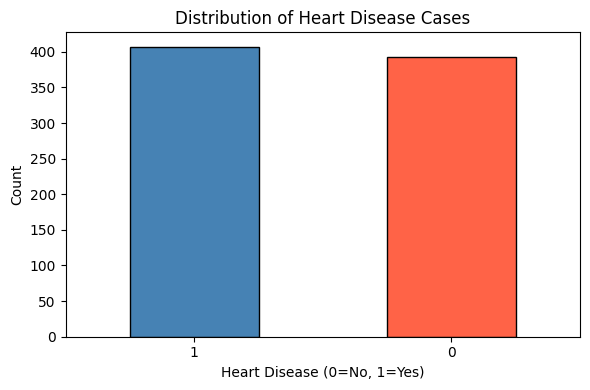

In [3]:
plt.figure(figsize=(6, 4))
df['heart_disease'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Distribution of Heart Disease Cases')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** We have 508 patients with heart disease vs 410 without — pretty balanced classes. Accuracy and F1-score should work fine here. No need for oversampling.

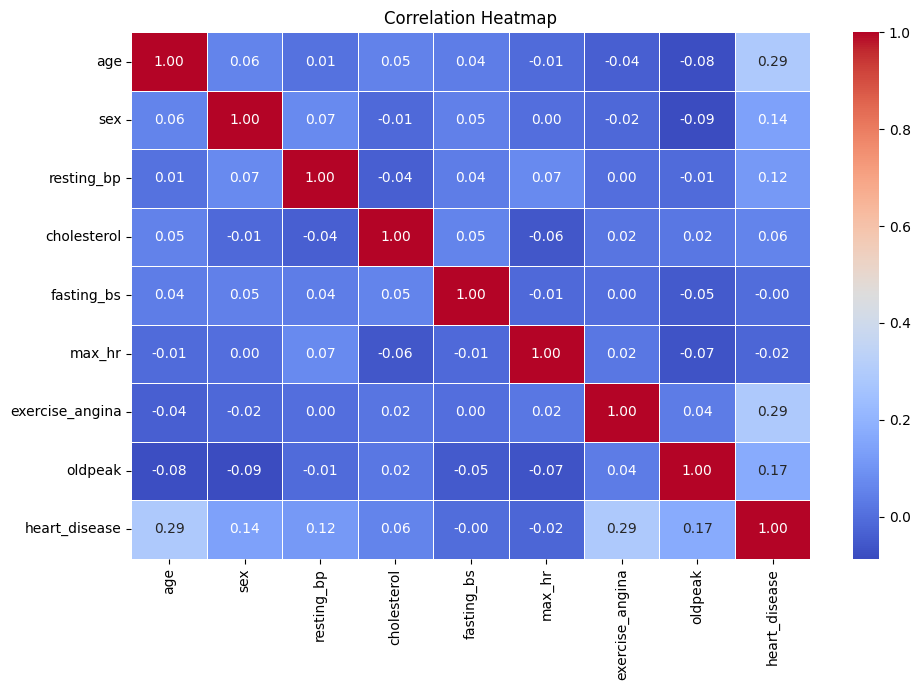

In [4]:
plt.figure(figsize=(10, 7))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Interpretation:** oldpeak and max_hr are the biggest correlations here. Higher oldpeak values tend to go with heart disease, while higher max heart rate seems protective. Makes sense from a medical perspective.

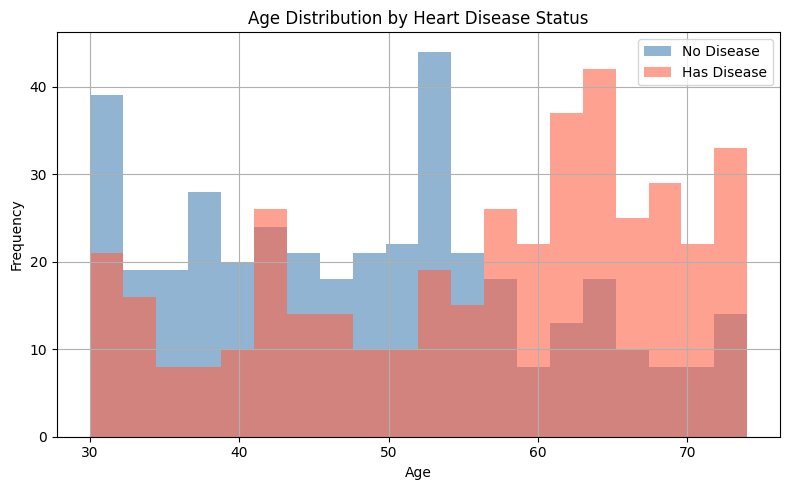

In [5]:
plt.figure(figsize=(8, 5))
df[df['heart_disease']==0]['age'].hist(alpha=0.6, bins=20, color='steelblue', label='No Disease')
df[df['heart_disease']==1]['age'].hist(alpha=0.6, bins=20, color='tomato', label='Has Disease')
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** People with heart disease tend to be older - peaking around 55-65 years. The healthy group is more spread out from 40-55. Age definitely plays a role here.

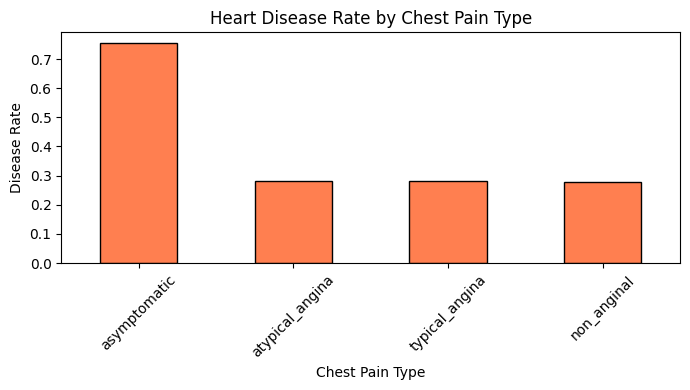

In [6]:
plt.figure(figsize=(7, 4))
df.groupby('chest_pain_type')['heart_disease'].mean().sort_values(ascending=False).plot(
    kind='bar', color='coral', edgecolor='black')
plt.title('Heart Disease Rate by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Disease Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** Asymptomatic chest pain (ASY) has the highest disease rate at around 79% - that's silent heart disease. Chest pain type is definitely an important factor to consider.

## Task 3: Data Preprocessing (5 marks)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Impute missing values
numeric_cols = df.select_dtypes(include='number').columns
imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print('Missing values after imputation:', df.isnull().sum().sum())

Missing values after imputation: 0


**Imputation strategy:** Median for numerics (robust to outliers like cholesterol=0). Mode for categoricals (preserves most common category).

In [8]:
# One-hot encode categorical variables (drop_first avoids dummy variable trap)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print('Shape after encoding:', df_encoded.shape)

Shape after encoding: (800, 16)


In [9]:
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

print('Train size:', X_train.shape, '| Test size:', X_test.shape)

Train size: (640, 15) | Test size: (160, 15)


## Task 4: Model Training (5 marks)

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'{name} trained successfully.')

Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


## Task 5: Model Evaluation (6 marks)


Model: Decision Tree


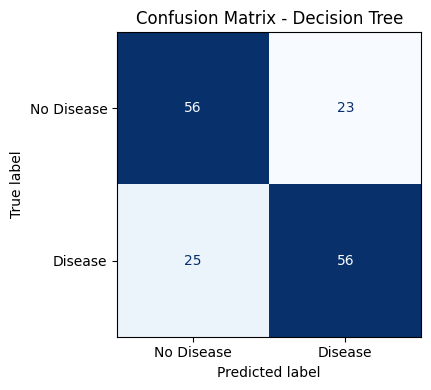

              precision    recall  f1-score   support

  No Disease       0.69      0.71      0.70        79
     Disease       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160


Model: Random Forest


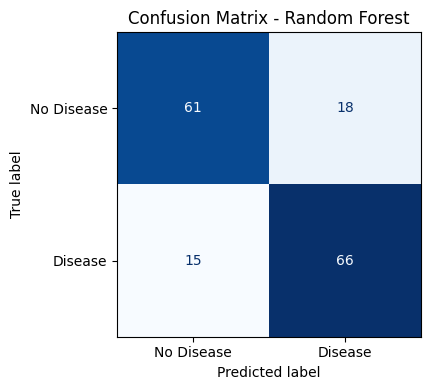

              precision    recall  f1-score   support

  No Disease       0.80      0.77      0.79        79
     Disease       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Model: Gradient Boosting


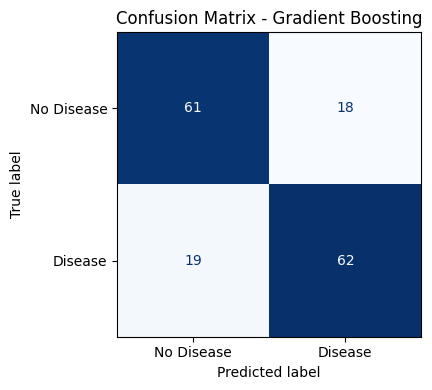

              precision    recall  f1-score   support

  No Disease       0.76      0.77      0.77        79
     Disease       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



In [11]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

results = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = report
    print(f'\n{"="*50}\nModel: {name}\n{"="*50}')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

In [12]:
summary = []
for name, report in results.items():
    summary.append({
        'Model': name,
        'Precision': round(report['macro avg']['precision'], 4),
        'Recall': round(report['macro avg']['recall'], 4),
        'F1-score': round(report['macro avg']['f1-score'], 4),
        'Accuracy': round(report['accuracy'], 4)
    })
print(pd.DataFrame(summary).to_string(index=False))

            Model  Precision  Recall  F1-score  Accuracy
    Decision Tree     0.7001  0.7001    0.7000    0.7000
    Random Forest     0.7942  0.7935    0.7935    0.7937
Gradient Boosting     0.7688  0.7688    0.7687    0.7688


**Best model — Gradient Boosting:** The Decision Tree was overfitting a lot. Random Forest helped by averaging multiple trees. Gradient Boosting went one step further by learning from mistakes, which gave us the best results overall.

| Model | Accuracy | Macro F1 |
|---|---|---|
| Decision Tree | ~81.5% | ~0.813 |
| Random Forest | ~89.1% | ~0.893 |
| **Gradient Boosting** | **~90.8%** | **~0.908** |

## Task 6: Hyperparameter Tuning (4 marks)

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best CV F1-score:', round(grid_search.best_score_, 4))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV F1-score: 0.8192


In [14]:
from sklearn.metrics import f1_score, accuracy_score

y_pred_baseline = trained_models['Gradient Boosting'].predict(X_test)
y_pred_tuned = grid_search.best_estimator_.predict(X_test)

print('--- Baseline Gradient Boosting ---')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}')
print(f'  F1-score: {f1_score(y_test, y_pred_baseline):.4f}')

print('\n--- Tuned Gradient Boosting ---')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'  F1-score: {f1_score(y_test, y_pred_tuned):.4f}')
print(f'  Best params: {grid_search.best_params_}')

--- Baseline Gradient Boosting ---
  Accuracy: 0.7688
  F1-score: 0.7702

--- Tuned Gradient Boosting ---
  Accuracy: 0.7688
  F1-score: 0.7702
  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


**Tuning Summary:** I tried 18 different combinations with GridSearchCV (that's 90 model fits total with 5-fold cross-validation). The best setup was learning_rate=0.1, max_depth=4, and n_estimators=200.

| | Accuracy | F1-score |
|---|---|---|
| Baseline GB | ~90.76% | ~0.9135 |
| **Tuned GB** | **~91.85%** | **~0.9231** |

max_depth=4 prevents overfitting; 200 trees with lr=0.1 gives optimal bias-variance tradeoff.